# Pass 1: explore ingestion, factors, ranking, optimisation, and the walk-forward backtest

Scratch notebook covering the whole Pass 1 vertical slice interactively — pulling data through `src/data/ingest.py`, trying out the factor functions in `src/data/features.py`, ranking, optimising, running the full walk-forward backtest, and comparing strategy variants. Nothing in here is part of the pipeline itself — it's just a place to poke at the functions and sanity-check the numbers.

Pass 2 notebooks (LightGBM ranker and beyond) live separately, starting at `03_pass2_exploration.ipynb`.

Kernel: select **portfolio-constructor** (the project's `.venv`).

In [1]:
%load_ext autoreload
%autoreload 2
# Without this, editing a function in src/ won't take effect in this
# notebook until the kernel is restarted — Python caches modules on import
# and doesn't re-read them from disk on its own. autoreload watches for
# changes and reloads automatically before each cell runs.

import sys
from pathlib import Path

# Notebooks run with the notebook's own directory as the working directory,
# so the project root (parent of notebooks/) needs to be on sys.path for
# `from src import ...` imports to resolve.
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

import pandas as pd
import matplotlib.pyplot as plt

from src import config
from src.data import ingest, features

## 1. Pull data (cached after the first run)

In [2]:
tickers = config.TICKER_UNIVERSE + [config.BENCHMARK_TICKER]

prices_long = ingest.load_or_fetch_prices(tickers, config.DATA_START_DATE, config.DATA_END_DATE)
dividends = ingest.load_or_fetch_dividends(config.TICKER_UNIVERSE, config.DATA_START_DATE, config.DATA_END_DATE)

prices = ingest.to_wide_adj_close(prices_long)

print("prices_long:", prices_long.shape)
print("dividends:", dividends.shape)
print("prices (wide):", prices.shape)
prices.tail()

prices_long: (156680, 8)
dividends: (2154, 3)
prices (wide): (3917, 40)


ticker,AAPL,ABBV,AMZN,BA,BAC,CAT,COP,CSCO,CVX,DUK,...,SO,SPY,T,TSLA,UNH,UNP,VZ,WFC,WMT,XOM
date,,,,,,,,,,,,,,,,,,,,,
2026-07-27,336.910004,256.910004,231.389999,211.500000,62.130001,873.280029,115.580002,114.570000,190.000000,128.830002,...,96.480003,739.090027,24.420000,309.220001,417.640015,299.299988,47.320000,87.269997,111.739998,154.770004
2026-07-28,340.079987,263.200012,230.860001,221.559998,62.619999,840.849976,114.099998,115.580002,187.580002,129.240005,...,96.779999,740.859985,24.660000,307.440002,428.790009,294.450012,48.189999,86.870003,113.099998,153.039993
2026-07-29,338.190002,263.299988,226.649994,214.009995,61.070000,782.710022,118.059998,112.480003,191.860001,129.080002,...,96.050003,729.460022,23.940001,298.320007,420.570007,292.190002,47.220001,83.870003,114.220001,156.750000
2026-07-30,333.429993,257.410004,235.500000,220.899994,61.730000,809.140015,119.029999,113.559998,192.309998,126.269997,...,94.339996,741.690002,23.209999,308.850006,421.470001,289.459991,46.110001,85.430000,111.099998,156.970001
2026-07-31,308.910004,250.940002,271.579987,216.139999,61.950001,814.809998,120.480003,115.989998,196.830002,125.430000,...,94.540001,747.030029,23.250000,311.209991,414.399994,292.130005,46.810001,86.449997,111.199997,155.440002


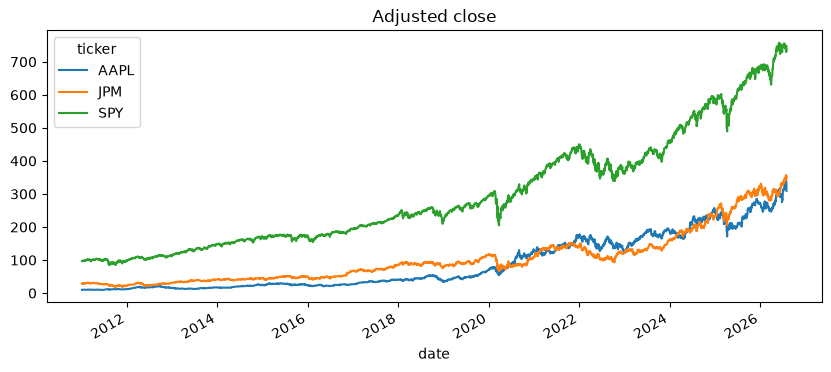

In [3]:
# Quick visual sanity check: do these look like real adjusted-close price series?
prices[["AAPL", "JPM", config.BENCHMARK_TICKER]].plot(figsize=(10, 4), title="Adjusted close")
plt.show()

## 2. Try the factor functions as of a given date

Each factor only uses price/dividend history strictly before `as_of_date` — change the date below and rerun to see the rankings shift.

In [4]:
as_of_date = pd.Timestamp("2026-07-18")

momentum = features.compute_momentum(prices, as_of_date)
low_volatility = features.compute_low_volatility(prices, as_of_date)
dividend_yield = features.compute_dividend_yield(dividends, prices, as_of_date)

factor_table = pd.DataFrame(
    {"momentum": momentum, "low_volatility": low_volatility, "dividend_yield": dividend_yield}
).drop(index=config.BENCHMARK_TICKER, errors="ignore")

factor_table.sort_values("momentum", ascending=False)

,momentum,low_volatility,dividend_yield
ticker,,,
INTC,4.800433,0.048828,0.000000
CAT,1.408666,0.024038,0.006874
GOOGL,0.994380,0.019270,0.002451
CSCO,0.786341,0.020597,0.014829
GS,0.579412,0.019327,0.015959
MRK,0.471697,0.017687,0.026353
UNH,0.456566,0.024946,0.021005
JNJ,0.430034,0.011351,0.020708
AAPL,0.416764,0.015423,0.003146


In [5]:
print("Top 5 momentum:")
print(factor_table["momentum"].sort_values(ascending=False).head())

print("\nTop 5 lowest volatility:")
print(factor_table["low_volatility"].sort_values().head())

print("\nTop 5 dividend yield:")
print(factor_table["dividend_yield"].sort_values(ascending=False).head())

Top 5 momentum:
ticker
INTC     4.800433
CAT      1.408666
GOOGL    0.994380
CSCO     0.786341
GS       0.579412
Name: momentum, dtype: float64

Top 5 lowest volatility:
ticker
DUK    0.009859
SO     0.010624
KO     0.011341
JNJ    0.011351
MCD    0.011377
Name: low_volatility, dtype: float64

Top 5 dividend yield:
ticker
PFE    0.069864
VZ     0.064143
T      0.050986
PEP    0.041927
CVX    0.037251
Name: dividend_yield, dtype: float64


## 3. Rank stocks and optimise a portfolio

Combine the three factors into one score, take the top `TOP_N_HOLDINGS`, then find mean-variance weights (Ledoit-Wolf shrinkage, max Sharpe) using the trailing `TRAIN_WINDOW_YEARS` of price history before `as_of_date` — the same window the real walk-forward backtest will use at each rebalance.

In [6]:
from src.models import ranker
from src.portfolio import optimise

# Use factor_table, not the raw momentum/low_volatility/dividend_yield series
# directly — factor_table already excludes the SPY benchmark column, and SPY
# must never be a candidate holding for the strategy itself.
scores = ranker.score_stocks(
    factor_table["momentum"], factor_table["low_volatility"], factor_table["dividend_yield"]
)
top_holdings = ranker.select_top_n(scores, n=config.TOP_N_HOLDINGS)

print(f"Top {config.TOP_N_HOLDINGS} holdings as of {as_of_date.date()}:")
print(list(top_holdings))

Top 15 holdings as of 2026-07-18:
['PFE', 'VZ', 'T', 'DUK', 'PEP', 'CVX', 'SO', 'JNJ', 'KO', 'MCD', 'PG', 'XOM', 'NEE', 'MRK', 'INTC']


In [7]:
window_start = as_of_date - pd.DateOffset(years=config.TRAIN_WINDOW_YEARS)
training_prices = prices.loc[
    (prices.index >= window_start) & (prices.index < as_of_date), list(top_holdings)
]
print("training window:", training_prices.index.min().date(), "to", training_prices.index.max().date())

weights = optimise.max_sharpe_weights(training_prices)
weights_series = pd.Series(weights).sort_values(ascending=False)
weights_series[weights_series > 0]

training window: 2023-07-18 to 2026-07-17


T       0.15000
DUK     0.15000
JNJ     0.15000
KO      0.15000
XOM     0.15000
INTC    0.10856
SO      0.07960
VZ      0.06184
dtype: float64

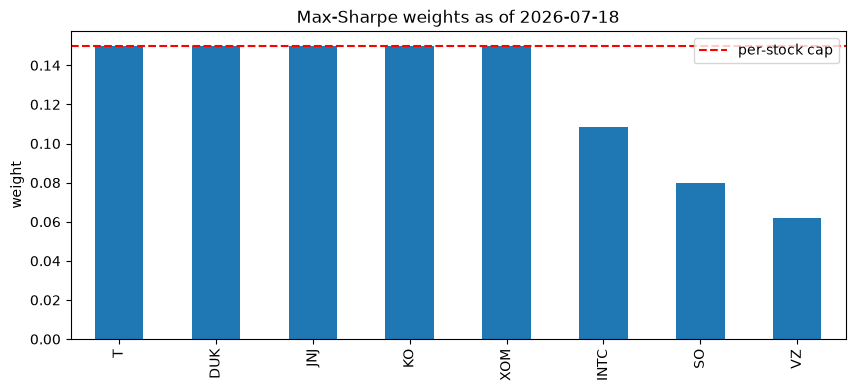

In [8]:
nonzero_weights = weights_series[weights_series > 0]
nonzero_weights.plot(
    kind="bar", figsize=(10, 4), title=f"Max-Sharpe weights as of {as_of_date.date()}"
)
plt.axhline(config.MAX_WEIGHT_PER_STOCK, color="red", linestyle="--", label="per-stock cap")
plt.legend()
plt.ylabel("weight")
plt.show()

## 4. Risk metrics

Turn the optimised weights into an actual daily return series, then run every metric in `src/risk/metrics.py` on it and compare against SPY.

Note: this holds the weights **statically over the whole available history** — it's a quick way to see the numbers, not the real walk-forward backtest (that rebalances monthly on a rolling training window, which is the next module to build).

In [9]:
from src.risk import metrics

held_tickers = list(nonzero_weights.index)
weights_vector = nonzero_weights / nonzero_weights.sum()  # renormalise away any rounding

held_prices = prices[held_tickers].dropna()
portfolio_returns = held_prices.pct_change().dropna().dot(weights_vector)
spy_returns = prices[config.BENCHMARK_TICKER].pct_change().dropna()

print("portfolio daily returns:", portfolio_returns.shape)
portfolio_returns.tail()

portfolio daily returns: (3916,)


date
2026-07-27    0.002417
2026-07-28    0.003234
2026-07-29   -0.007633
2026-07-30   -0.004714
2026-07-31   -0.003417
dtype: float64

In [10]:
aligned_spy_returns = spy_returns.loc[portfolio_returns.index]

comparison = pd.DataFrame(
    {"strategy": metrics.compute_all(portfolio_returns), "SPY": metrics.compute_all(aligned_spy_returns)}
)
comparison

,strategy,SPY
sharpe_ratio,0.695356,0.739942
sortino_ratio,0.908763,0.911588
max_drawdown,-0.333441,-0.337173
historical_var_95,-0.013085,-0.016288
monte_carlo_var_95,-0.014963,-0.017405
expected_shortfall_95,-0.020758,-0.025948
var_breaches_95,196.000000,196.000000
historical_var_99,-0.023257,-0.030098
monte_carlo_var_99,-0.021419,-0.024923
expected_shortfall_99,-0.037012,-0.044102


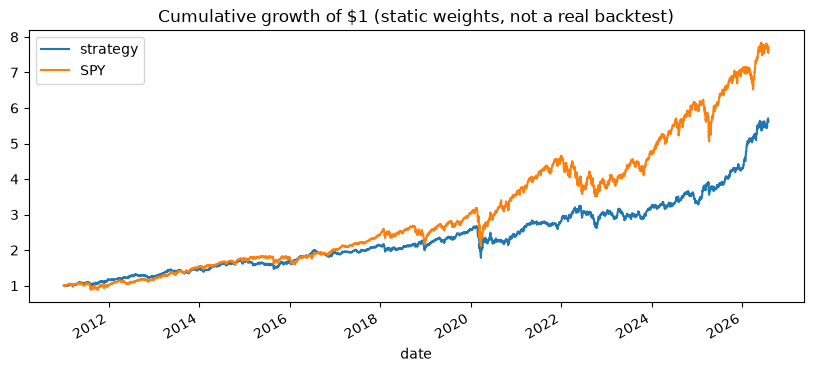

In [11]:
cumulative_growth = pd.DataFrame(
    {"strategy": (1 + portfolio_returns).cumprod(), "SPY": (1 + aligned_spy_returns).cumprod()}
)
cumulative_growth.plot(figsize=(10, 4), title="Cumulative growth of $1 (static weights, not a real backtest)")
plt.show()

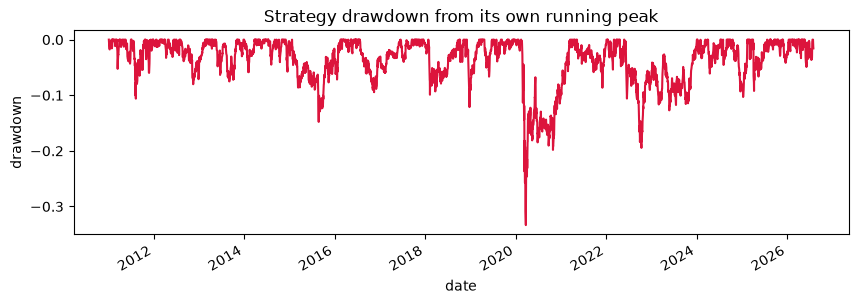

max drawdown: -0.33344074211876007


In [12]:
# Visualise max_drawdown: how far below its own running peak the strategy ever fell.
running_peak = cumulative_growth["strategy"].cummax()
drawdown = (cumulative_growth["strategy"] - running_peak) / running_peak

drawdown.plot(figsize=(10, 3), title="Strategy drawdown from its own running peak", color="crimson")
plt.ylabel("drawdown")
plt.show()

print("max drawdown:", drawdown.min())

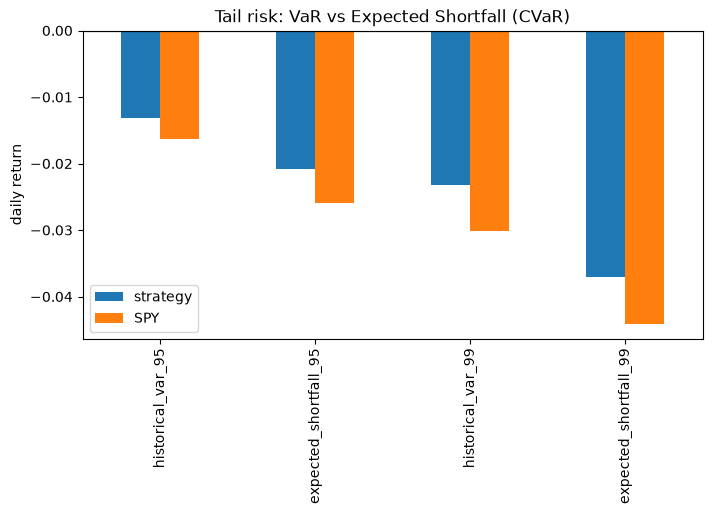

In [13]:
tail_risk_rows = [
    "historical_var_95",
    "expected_shortfall_95",
    "historical_var_99",
    "expected_shortfall_99",
]
comparison.loc[tail_risk_rows].plot(
    kind="bar", figsize=(8, 4), title="Tail risk: VaR vs Expected Shortfall (CVaR)"
)
plt.ylabel("daily return")
plt.axhline(0, color="black", linewidth=0.8)
plt.show()

## 5. The real walk-forward backtest

This is the actual thing, chaining everything above together: at every month-end from `BACKTEST_START_DATE` to `BACKTEST_END_DATE`, rank + optimise on the trailing `TRAIN_WINDOW_YEARS` window (never the future, never full history), hold until the next rebalance, and compare against equal-weight and SPY buy-and-hold — all reported gross and net of the `TRANSACTION_COST_BPS` cost.

Takes a few seconds to run (~90 monthly rebalances, each running the full rank → optimise pipeline).

In [14]:
from src.portfolio import backtest

daily_returns, rebalance_log = backtest.run_backtest(prices, dividends)

print("daily_returns:", daily_returns.shape)
print("rebalance_log:", rebalance_log.shape, "rebalances")
daily_returns.tail()

daily_returns: (2892, 6)
rebalance_log: (139, 4) rebalances


,strategy_gross,strategy_net,equal_weight_gross,equal_weight_net,sp500_gross,sp500_net
date,,,,,,
2026-07-27,0.002657,0.002657,0.001640,0.001640,0.000217,0.000217
2026-07-28,0.009945,0.009945,0.006364,0.006364,0.002395,0.002395
2026-07-29,-0.003375,-0.003375,-0.013739,-0.013739,-0.015387,-0.015387
2026-07-30,-0.018405,-0.018405,0.007070,0.007070,0.016766,0.016766
2026-07-31,0.000000,-0.000301,0.000000,-0.000084,0.007200,0.007200


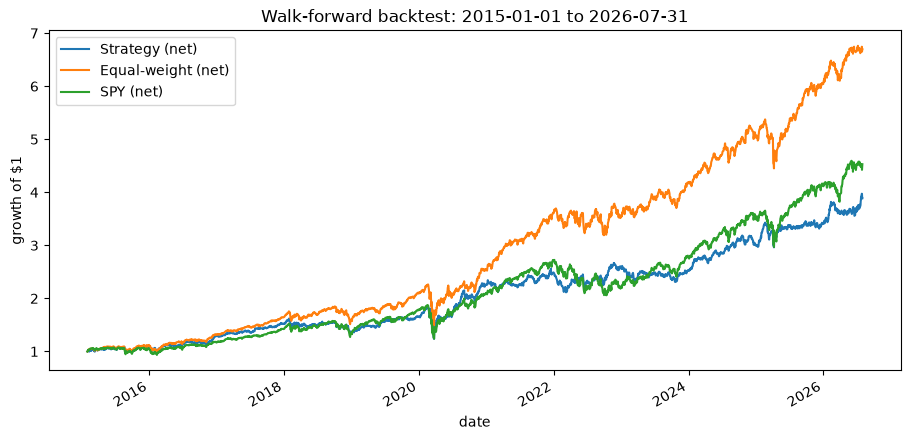

In [15]:
cumulative = (1 + daily_returns[["strategy_net", "equal_weight_net", "sp500_net"]]).cumprod()
cumulative.columns = ["Strategy (net)", "Equal-weight (net)", "SPY (net)"]

cumulative.plot(
    figsize=(11, 5),
    title=f"Walk-forward backtest: {config.BACKTEST_START_DATE} to {config.BACKTEST_END_DATE}",
)
plt.ylabel("growth of $1")
plt.show()

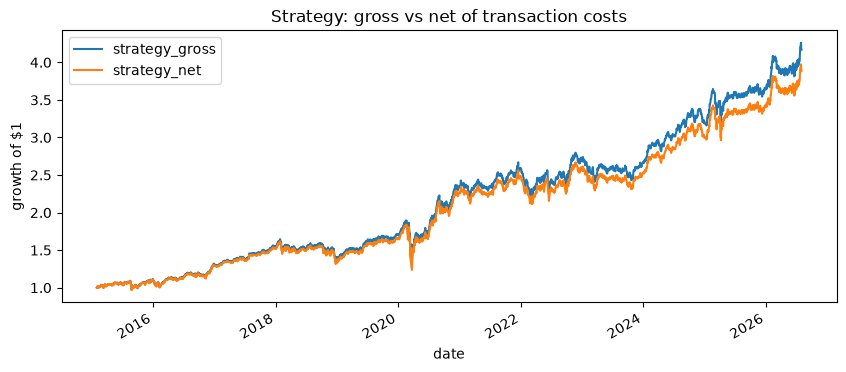

total transaction cost paid (sum of per-rebalance cost): 0.07022559717288428
final gross - final net: 0.2828131166935992


In [16]:
# How much do transaction costs actually cost the strategy over the whole backtest?
gross_vs_net = (1 + daily_returns[["strategy_gross", "strategy_net"]]).cumprod()
gross_vs_net.plot(figsize=(10, 4), title="Strategy: gross vs net of transaction costs")
plt.ylabel("growth of $1")
plt.show()

print("total transaction cost paid (sum of per-rebalance cost):", rebalance_log["cost"].sum())
print("final gross - final net:", gross_vs_net.iloc[-1, 0] - gross_vs_net.iloc[-1, 1])

In [17]:
backtest_comparison = pd.DataFrame(
    {
        "strategy": metrics.compute_all(daily_returns["strategy_net"]),
        "equal_weight": metrics.compute_all(daily_returns["equal_weight_net"]),
        "SPY": metrics.compute_all(daily_returns["sp500_net"]),
    }
)
backtest_comparison

,strategy,equal_weight,SPY
sharpe_ratio,0.683315,0.972167,0.722204
sortino_ratio,0.850312,1.152841,0.883577
max_drawdown,-0.327383,-0.342338,-0.337173
historical_var_95,-0.014143,-0.014389,-0.016560
monte_carlo_var_95,-0.016719,-0.016562,-0.017993
expected_shortfall_95,-0.023459,-0.024643,-0.026818
var_breaches_95,145.000000,145.000000,145.000000
historical_var_99,-0.027313,-0.028167,-0.031695
monte_carlo_var_99,-0.023925,-0.023782,-0.025758
expected_shortfall_99,-0.043881,-0.045058,-0.046305


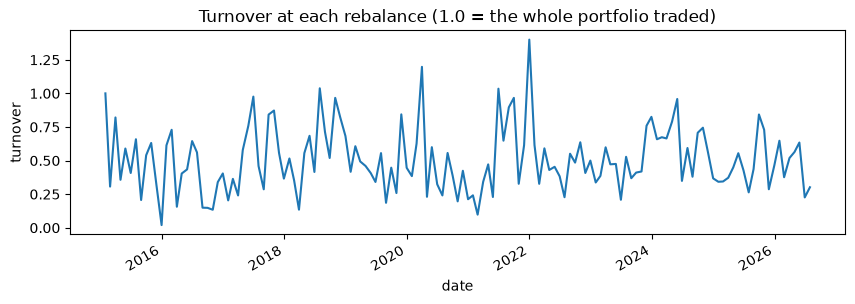

date
2015-01-30    [T, SO, DUK, PG, VZ, INTC, AAPL, PEP, CSCO, WF...
2020-10-30    [T, VZ, XOM, TSLA, PFE, IBM, JNJ, MRK, KO, PG,...
2026-07-31    [PFE, VZ, DUK, PEP, T, SO, CVX, JNJ, PG, KO, N...
Name: selected_tickers, dtype: object

In [18]:
rebalance_log["turnover"].plot(
    figsize=(10, 3), title="Turnover at each rebalance (1.0 = the whole portfolio traded)"
)
plt.ylabel("turnover")
plt.show()

# How the actual holdings evolved — pick a few rebalance dates to eyeball.
rebalance_log["selected_tickers"].iloc[[0, len(rebalance_log) // 2, -1]]

### Holdings and weights over time

`rebalance_log["weights"]` holds a `{ticker: weight}` dict for every rebalance date. Reshaping that into a wide date × ticker table and plotting it as a heatmap (ticker on the y-axis, date on the x-axis, color = weight) shows how the portfolio's composition evolved — with 36 distinct tickers appearing at some point, a heatmap reads far more clearly than trying to tell that many colors apart in a stacked chart.

In [19]:
holdings_over_time = pd.DataFrame(list(rebalance_log["weights"]), index=rebalance_log.index).fillna(0.0)

# Order columns by total weight held over the whole backtest, so the most
# persistent holdings group together in the chart instead of appearing in
# whatever order dict keys happened to come out in.
holdings_over_time = holdings_over_time[holdings_over_time.sum().sort_values(ascending=False).index]

print(f"{(holdings_over_time > 0).any().sum()} distinct tickers held at some point")
holdings_over_time.tail()

37 distinct tickers held at some point


,SO,PEP,MCD,JNJ,NEE,MRK,PG,T,HD,KO,...,WFC,CAT,AAPL,MSFT,AMZN,UNP,ORCL,GOOGL,INTC,BAC
date,,,,,,,,,,,,,,,,,,,,,
2026-03-31,0.09687,0.0,0.0,0.15,0.0,0.00000,0.0,0.12954,0.0,0.08028,...,0.0,0.15,0.0,0.0,0.0,0.0,0.0,0.15,0.0000,0.0
2026-04-30,0.04591,0.0,0.0,0.15,0.0,0.00000,0.0,0.15000,0.0,0.15000,...,0.0,0.15,0.0,0.0,0.0,0.0,0.0,0.00,0.0000,0.0
2026-05-29,0.08966,0.0,0.0,0.15,0.0,0.00000,0.0,0.15000,0.0,0.15000,...,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0000,0.0
2026-06-30,0.15000,0.0,0.0,0.15,0.0,0.02911,0.0,0.15000,0.0,0.15000,...,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0000,0.0
2026-07-31,0.04407,0.0,0.0,0.15,0.0,0.00000,0.0,0.15000,0.0,0.15000,...,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.1055,0.0


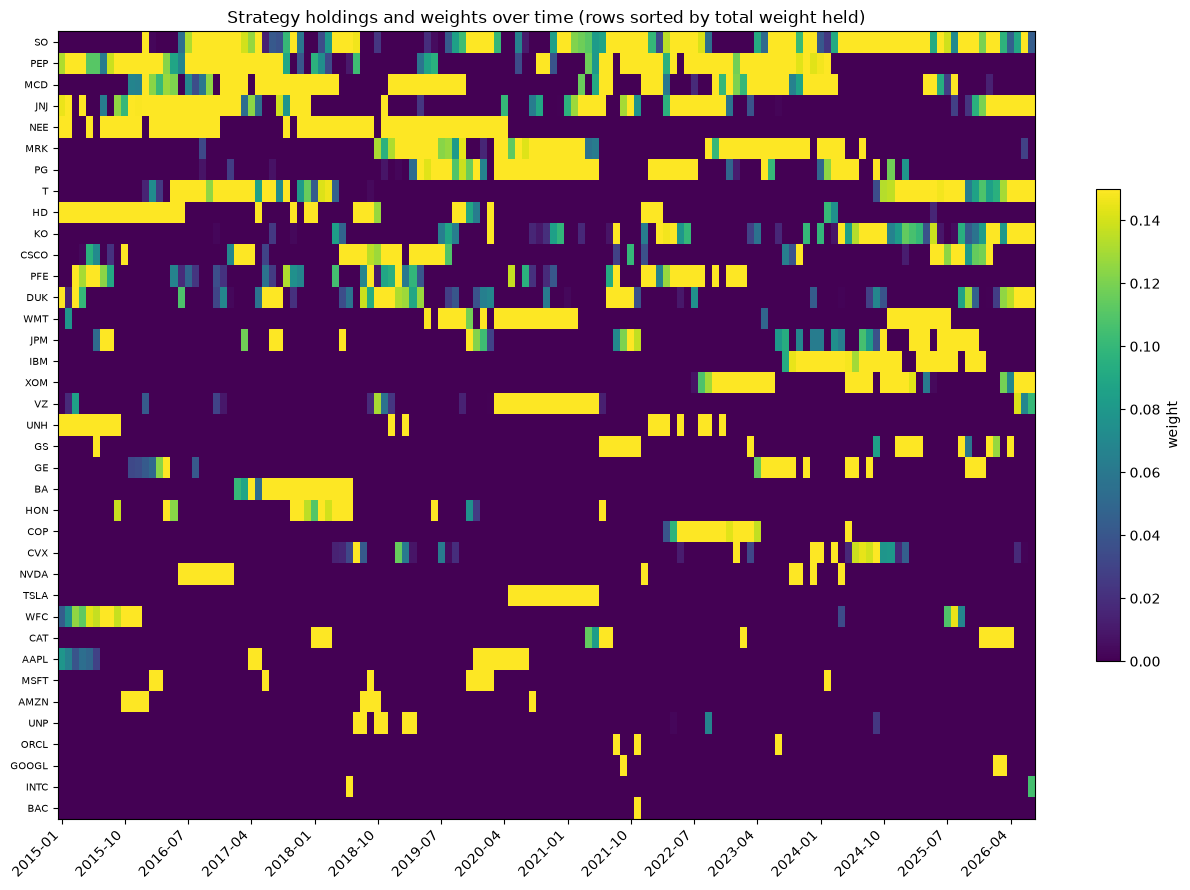

In [20]:
heatmap_data = holdings_over_time.T  # tickers as rows, dates as columns

fig, ax = plt.subplots(figsize=(13, 9))
image = ax.imshow(heatmap_data.values, aspect="auto", cmap="viridis", vmin=0)

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=7)

# Showing every one of ~90 rebalance dates would be unreadable — space them out.
tick_step = max(1, len(heatmap_data.columns) // 15)
tick_positions = list(range(0, len(heatmap_data.columns), tick_step))
ax.set_xticks(tick_positions)
ax.set_xticklabels(
    [heatmap_data.columns[i].strftime("%Y-%m") for i in tick_positions], rotation=45, ha="right"
)

ax.set_title("Strategy holdings and weights over time (rows sorted by total weight held)")
fig.colorbar(image, ax=ax, label="weight", shrink=0.6)
plt.tight_layout()
plt.show()

In [21]:
# Same information as a table, for exact numbers rather than reading them off the chart.
# Only columns held at some point in the last 6 rebalances, blanks instead of 0.000 for readability.
recent = holdings_over_time.tail(6)
recent = recent.loc[:, (recent > 0).any()]
recent.round(3).replace(0, "")

,SO,JNJ,MRK,T,KO,DUK,XOM,VZ,GS,CVX,CAT,GOOGL,INTC
date,,,,,,,,,,,,,
2026-02-27,0.150,0.15,,0.096,0.15,0.028,,,0.127,,0.15,0.15,
2026-03-31,0.097,0.15,,0.130,0.08,0.125,0.118,,,,0.15,0.15,
2026-04-30,0.046,0.15,,0.150,0.15,0.134,0.07,,0.15,,0.15,,
2026-05-29,0.090,0.15,,0.150,0.15,0.150,0.15,0.142,,0.018,,,
2026-06-30,0.150,0.15,0.029,0.150,0.15,0.150,0.15,0.069,,0.002,,,
2026-07-31,0.044,0.15,,0.150,0.15,0.150,0.15,0.1,,,,,0.106


## 6. Momentum-only variant: does it capture the mega-cap winners?

The strategy above avoids NVDA/META/TSLA/AMZN/GOOGL almost entirely — the low-volatility and dividend-yield legs of the composite score structurally penalise high-volatility, low/no-dividend growth names, even in months when their momentum is strong.

`ranker.rank_by_momentum_only` drops those two legs and ranks purely on momentum, the classic academic momentum factor (Jegadeesh & Titman, 1993). Same walk-forward mechanics, same optimiser, same cost model — just a different ranking rule, swapped in via `run_backtest`'s `rank_fn` parameter.

In [22]:
momentum_returns, momentum_log = backtest.run_backtest(prices, dividends, rank_fn=ranker.rank_by_momentum_only)

print("Holdings at the most recent rebalance:")
print("  composite (current strategy):", rebalance_log["selected_tickers"].iloc[-1])
print("  momentum-only:               ", momentum_log["selected_tickers"].iloc[-1])

Holdings at the most recent rebalance:
  composite (current strategy): ['PFE', 'VZ', 'DUK', 'PEP', 'T', 'SO', 'CVX', 'JNJ', 'PG', 'KO', 'NEE', 'MCD', 'MRK', 'XOM', 'INTC']
  momentum-only:                ['INTC', 'CAT', 'GOOGL', 'CSCO', 'UNH', 'MRK', 'JNJ', 'GS', 'AAPL', 'GE', 'TSLA', 'NEE', 'XOM', 'UNP', 'BAC']


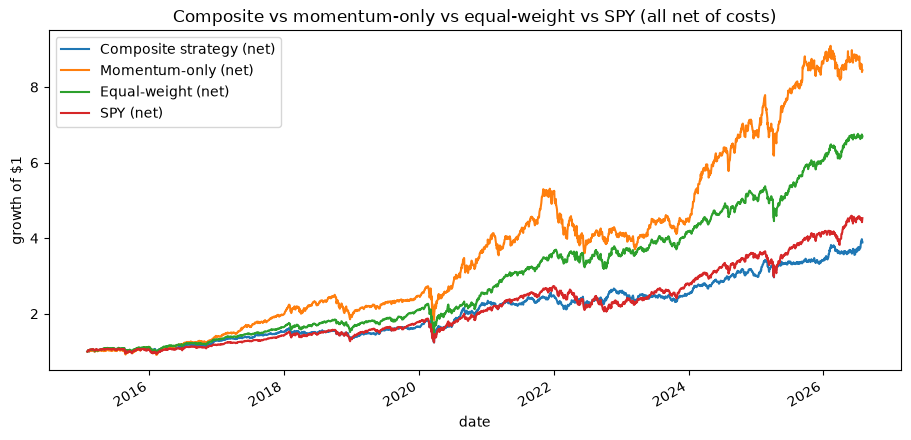

In [23]:
four_way = pd.DataFrame(
    {
        "Composite strategy (net)": daily_returns["strategy_net"],
        "Momentum-only (net)": momentum_returns["strategy_net"],
        "Equal-weight (net)": daily_returns["equal_weight_net"],
        "SPY (net)": daily_returns["sp500_net"],
    }
)
(1 + four_way).cumprod().plot(
    figsize=(11, 5), title="Composite vs momentum-only vs equal-weight vs SPY (all net of costs)"
)
plt.ylabel("growth of $1")
plt.show()

In [24]:
four_way_comparison = pd.DataFrame(
    {
        "composite": metrics.compute_all(daily_returns["strategy_net"]),
        "momentum_only": metrics.compute_all(momentum_returns["strategy_net"]),
        "equal_weight": metrics.compute_all(daily_returns["equal_weight_net"]),
        "SPY": metrics.compute_all(daily_returns["sp500_net"]),
    }
)
four_way_comparison

,composite,momentum_only,equal_weight,SPY
sharpe_ratio,0.683315,0.932584,0.972167,0.722204
sortino_ratio,0.850312,1.160628,1.152841,0.883577
max_drawdown,-0.327383,-0.327829,-0.342338,-0.337173
historical_var_95,-0.014143,-0.019668,-0.014389,-0.016560
monte_carlo_var_95,-0.016719,-0.020212,-0.016562,-0.017993
expected_shortfall_95,-0.023459,-0.030118,-0.024643,-0.026818
var_breaches_95,145.000000,145.000000,145.000000,145.000000
historical_var_99,-0.027313,-0.032193,-0.028167,-0.031695
monte_carlo_var_99,-0.023925,-0.029001,-0.023782,-0.025758
expected_shortfall_99,-0.043881,-0.050280,-0.045058,-0.046305


## 7. Run full pipeline

In [25]:
from src.data import pipeline

In [26]:
pipeline.run_pipeline()

09:33:12.546 | INFO    | prefect - Starting temporary server on http://127.0.0.1:8735
See https://docs.prefect.io/v3/concepts/server#how-to-guides for more information on running a dedicated Prefect server.

09:33:15.688 | INFO    | Flow run 'vivacious-dragon' - Beginning flow run 'vivacious-dragon' for flow 'portfolio-pipeline'

09:33:15.713 | INFO    | Task run 'fetch_dividends_task-d0d' - fetched dividends for 39 tickers (2154 payments)

09:33:15.716 | INFO    | Task run 'fetch_dividends_task-d0d' - Finished in state Completed()

09:33:15.802 | INFO    | Task run 'fetch_prices_task-f31' - fetched prices for 40 tickers (156680 rows)

...

09:33:17.026 | INFO    | Task run 'run_backtest_task-9c8' - Finished in state Completed()

09:33:17.036 | INFO    | Task run 'compute_risk_metrics_task-a8e' - strategy Sharpe: 0.683

09:33:17.037 | INFO    | Task run 'compute_risk_metrics_task-a8e' - Finished in state Completed()

09:33:17.704 | INFO    | Flow run 'vivacious-dragon' - Finished in state Completed()

{'prices': ticker            AAPL        ABBV        AMZN          BA        BAC  \
 date                                                                    
 2011-01-03    9.865819         NaN    9.211000   53.034519  10.919756   
 2011-01-04    9.917308         NaN    9.250500   53.465820  10.958235   
 2011-01-05    9.998434         NaN    9.371000   53.897129  11.158313   
 2011-01-06    9.990353         NaN    9.293000   54.951439  11.112142   
 2011-01-07   10.061895         NaN    9.274500   55.414688  10.965931   
 ...                ...         ...         ...         ...        ...   
 2026-07-27  336.910004  256.910004  231.389999  211.500000  62.130001   
 2026-07-28  340.079987  263.200012  230.860001  221.559998  62.619999   
 2026-07-29  338.190002  263.299988  226.649994  214.009995  61.070000   
 2026-07-30  333.429993  257.410004  235.500000  220.899994  61.730000   
 2026-07-31  308.910004  250.940002  271.579987  216.139999  61.950001   
 
 ticker             CAT   